In [1]:
import os, yaml, sys
import numpy as np
from sklearn.decomposition import IncrementalPCA
from torchvision.models.feature_extraction import create_feature_extractor
import torch
import cv2
import joblib
import matplotlib.pyplot as plt
import time
from einops import rearrange
from IPython.display import clear_output
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])
from useful_stuff.general_utils.utils import print_wise, is_empty, get_device
from useful_stuff.image_processing.utils import get_video_dimensions, read_video
from useful_stuff.image_processing.computational_models import get_relevant_output_layers, imgANN
# from image_processing.utils import concatenate_frames_batch, shuffle_frames
from image_processing.gaze_dep_models import preprocess_batch, extract_center_patches, sample_random_patches, capture_1917_movie_runs, extract_features_1917_movie, ipca_movie_patches, save_ipca_patch


In [41]:
from dataclasses import dataclass, field

device = 'mps'
@dataclass
class Cfg:
    sq_size = 384
    input_size = 384
    secs_to_skip = 5
    batch_size = 100
    patches_per_frame = 3
    frames_step = 3 # every how many frames we want to take a sample (due to high temporal autocorrelation we can skip)
    patches_overhead_sampling = 2 # how many patches we want more than the images we're gonna pass to the model (to avoid proper shuffling)
    tot_patches = 3
    n_components = 1000
    layer_idx = 23
    model_name = 'dino_v3_l'
    pkg = 'hf'
    sub_num = 4
    repetition = 0
    neu_fs = 100
    sq_side = 384
    run = 3
    pooling = "all"
    model_url = "facebook/dinov3-vitl16-pretrain-lvd1689m"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
mod_fs = config["movie_fs"]

In [3]:
# m = imgANN(cfg.model_name, cfg.pkg, cfg.pooling, repo_url=cfg.model_url, dtype=torch.float32)

In [ ]:
# fn = save_ipca_patch(paths, cfg.model_name, layers[cfg.layer_idx], cfg.n_components, cfg.sq_size, cfg.pooling)
# print(fn)
# ipca_obj = joblib.load(fn)


/Users/tizianocausin/1917_local/models/dino_v3_l_layer.23.mlp.down_proj_1000components_384x384patch_allpool.pkl


In [42]:
from image_processing.gaze_dep_models import save_ANN_features, save_pixelwise_luminance
from project_specific_utils.dataloader import load_concat_regressout_mod
from scipy.io import loadmat
import h5py
m = []
for i in [0, 10, 20]:
    full_model_name = f"{cfg.model_name}_{layers[i]}"
    # m = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50,)
    p = save_ANN_features(paths, full_model_name, cfg.sub_num, cfg.run, mod_fs, cfg.sq_side, cfg.n_components, cfg.pooling,)
    with h5py.File(p, "r") as f:
        m_temp = f["vecrep"][:][:,::10]
        m.append(m_temp)

In [43]:
p_pix = save_pixelwise_luminance(paths, "pixelwise_luminance", cfg.sub_num, cfg.run, mod_fs, 250,*(50,))
with h5py.File(p_pix, "r") as f:
    m_pix = f["vecrep"][:][:,::10]
m_pix_reshaped = m_pix.reshape(50, 50, 3,m_pix.shape[1], order='F')

0

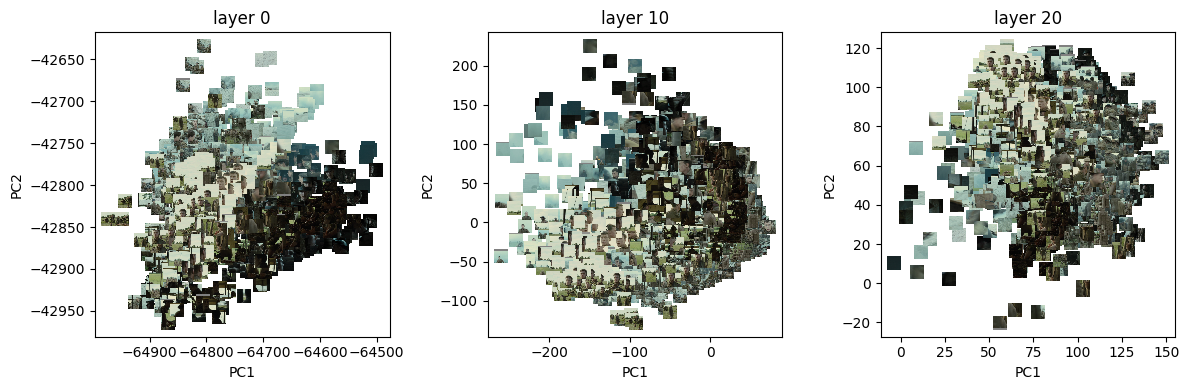

In [44]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for idx, idx_l in enumerate([0, 10, 20]):
    pts = m[idx][:, :]
    ax[idx].scatter(pts[0, :], pts[1, :], s=5, alpha=0.2)

    n = min(pts.shape[1], m_pix_reshaped.shape[-1])
    for t in range(n):
        img = m_pix_reshaped[..., t]
        ab = AnnotationBbox(
            OffsetImage(img, zoom=0.2),
            (pts[0, t], pts[1, t]),
            frameon=False
        )
        ax[idx].add_artist(ab)

    ax[idx].set_title(f"layer {idx_l}")
    ax[idx].set_xlabel("PC1")
    ax[idx].set_ylabel("PC2")

plt.tight_layout()
os.system('afplay /System/Library/Sounds/Ping.aiff')
    # ax[idx].scatter(m[idx][0, :], m[idx][1, :])


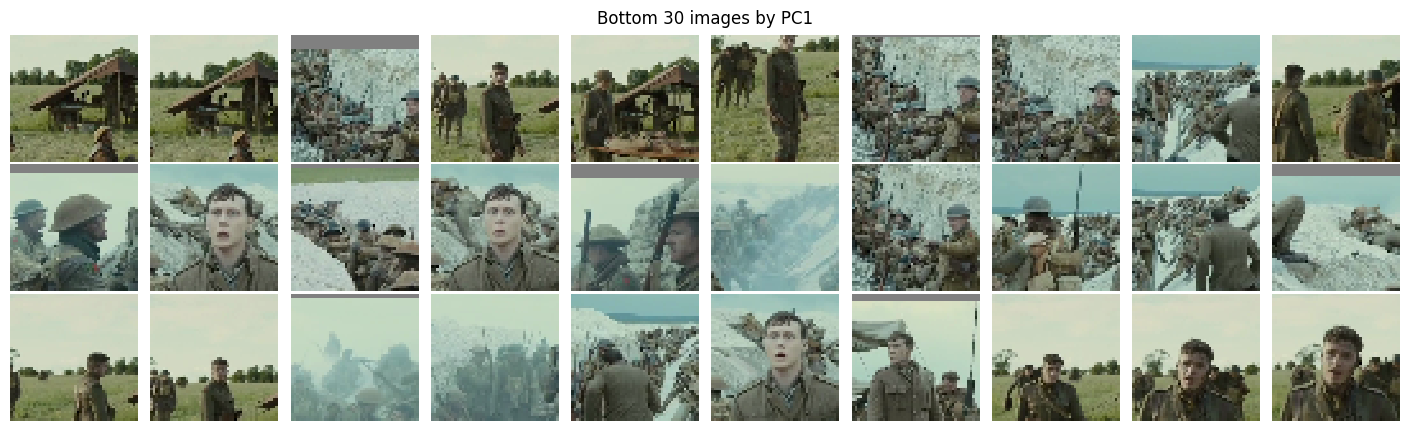

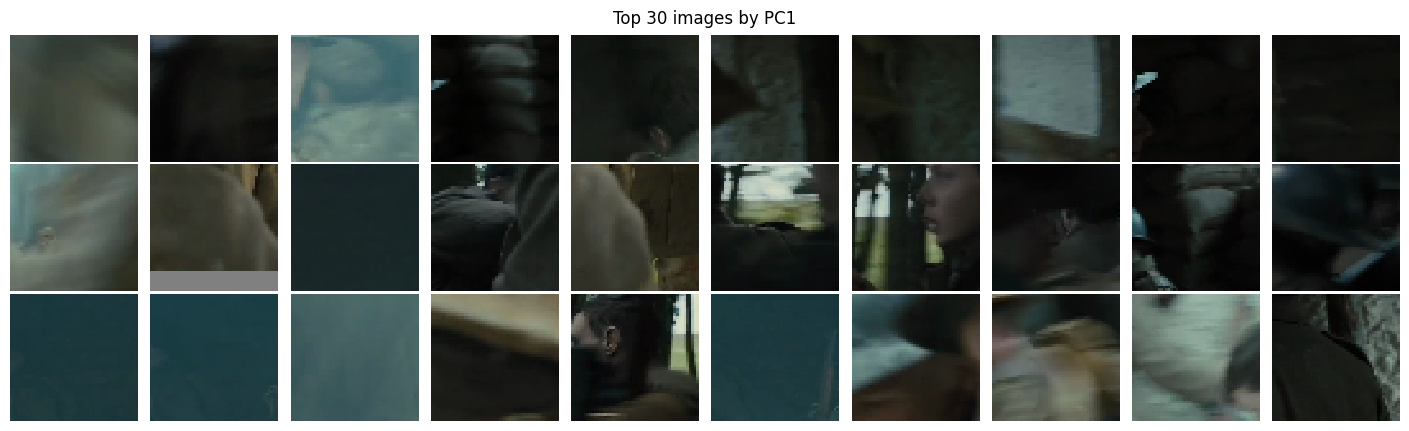

In [ ]:
pc1 = m[1][0, :]

order = np.argsort(pc1)
bottom_idx = order[:30]
top_idx = order[-30:][::-1]

def plot_tiled(indices, title, ncols=10):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(1.4 * ncols, 1.4 * nrows),
        gridspec_kw={"wspace": 0.02, "hspace": 0.02}
    )
    axes = np.array(axes).reshape(-1)

    for k, i in enumerate(indices):
        axes[k].imshow(m_pix_reshaped[:, :, :, i], interpolation="nearest")
        axes[k].axis("off")

    for k in range(n, len(axes)):
        axes[k].axis("off")

    fig.suptitle(title, fontsize=12)
    plt.subplots_adjust(left=0, right=1, top=0.92, bottom=0, wspace=0.02, hspace=0.02)
    plt.show()

plot_tiled(bottom_idx, "Bottom 30 images by PC1")
plot_tiled(top_idx, "Top 30 images by PC1")

In [36]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
m.create_forward_hook([layers[cfg.layer_idx]])
torch.cuda.empty_cache()
caps_list = capture_1917_movie_runs(paths)
fps = caps_list[0].get(cv2.CAP_PROP_FPS)
tot_frames = []
for start_f in [1500,]:
    start_s = start_f/fps
    for cap in caps_list:
        end_f = start_f+500
        end_s = end_f/fps
        v = read_video(paths, None, cap=cap, start=start_s, end=end_s, release=False, verbose=False)
        v = v[::cfg.frames_step*10]
        v = extract_center_patches(v, cfg.sq_size)
        if tot_frames is None:
            tot_frames = v
        else:
            tot_frames.extend(v)# = torch.concatenate((tot_frames, v), dim=0)
        # end if tot_frames is None:
    chunk = sample_random_patches(tot_frames, 100)
preproc_chunk = preprocess_batch(chunk, cfg.input_size, device=device)

with torch.no_grad():
    m.model(preproc_chunk)


pts = m.features[layers[cfg.layer_idx]].detach().cpu().numpy() @ ipca_obj.components_.T

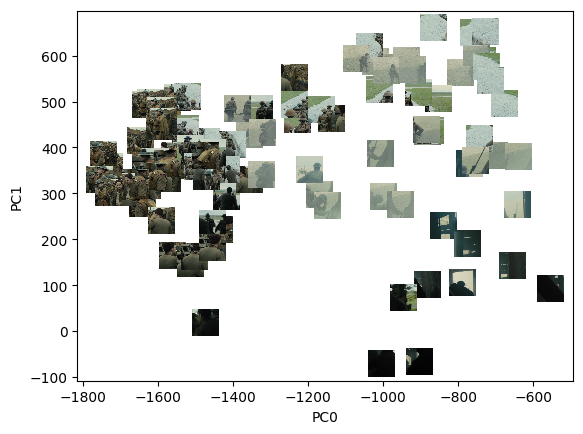

In [37]:
fig, ax = plt.subplots()

# scatter points (optional, for reference)
dims = (0,1)
ax.scatter(pts[:, dims[0]], pts[:, dims[1]])
ax.set_xlabel(f"PC{dims[0]}")
ax.set_ylabel(f"PC{dims[1]}")

# overlay images
for i in range(pts.shape[0]):
    # ensure image is in (H, W, C) and in [0,1] or [0,255]
    x = pts[i, dims[0]]
    y = pts[i, dims[1]]
    c = chunk[i, :].detach().cpu().numpy()
    # m = np.abs(c).max()
    # c_min, c_max = c.min(), c.max()
    # img = (c - c_min) / (c_max - c_min + 1e-8)
    # img = c.transpose(1,2,0)
    image = OffsetImage(c, zoom=0.05, alpha=1)

    ab = AnnotationBbox(image, (x, y), frameon=False)
    ax.add_artist(ab)
plt.show()

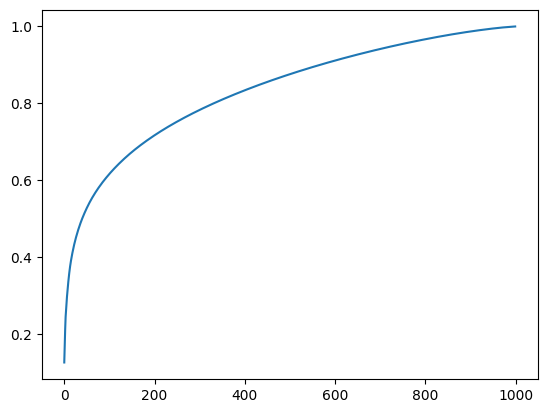

In [31]:
plt.plot(np.cumsum(ipca_obj.explained_variance_ratio_))

# TODO do this also for already extracted and projected features